# Assignment 1 - Matrix multiplication in Numba


We consider the problem of evaluating the matrix multiplication $C = A\times B$ for matrices $A, B\in\mathbb{R}^{n\times n}$.
A simple Python implementation of the matrix-matrix product is given below through the function `matrix_product`. At the end this
function is checked against the Numpy implementation of the matrix-matrix product.

In [1]:
import numpy as np

def matrix_product(mat_a, mat_b):
    """Returns the product of the matrices mat_a and mat_b."""
    m = mat_a.shape[0]
    n = mat_b.shape[1]

    assert(mat_a.shape[1] == mat_b.shape[0])

    ncol = mat_a.shape[1]

    mat_c = np.zeros((m, n), dtype=np.float64)

    for row_ind in range(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]

    return mat_c

a = np.random.randn(10, 10)
b = np.random.randn(10, 10)

c_actual = matrix_product(a, b)
c_expected = a @ b

error = np.linalg.norm(c_actual - c_expected) / np.linalg.norm(c_expected)
print(f"The error is {error}.")


The error is 8.698522008901743e-17.


The matrix product is one of the most fundamental operations on modern computers. Most algorithms eventually make use of this operation. A lot of effort is therefore spent on optimising the matrix product. Vendors provide hardware optimised BLAS (Basis Linear Algebra Subroutines) that provide highly efficient versions of the matrix product. Alternatively, open-source libraries sucha as Openblas provide widely used generic open-source implementations of this operation.

In this assignment we want to learn at the example of matrix-matrix products about the possible speedups offered by Numba, and the effects of cache-efficient programming.

## 1.1 Benchmark
Benchmark the above function against the Numpy dot product for matrix sizes up to 1000. Plot the timing results of the above function against the timing results for the Numpy dot product. You need not benchmark every dimension up to 1000. Figure out what dimensions to use so that you can represent the result without spending too much time waiting for the code to finish. To perform benchmarks you can use the `%timeit` magic command. An example is

    ```
    timeit_result = %timeit -o matrix_product(a, b)
    print(timeit_result.best)
    ```

## 1.2 Optimize
Now optimise the code by using Numba to JIT-compile it. Also, there is lots of scope for parallelisation in the code. You can for example parallelize the outer-most for-loop. Benchmark the JIT-compiled serial code against the JIT-compiled parallel code. Comment on the expected performance on your system against the observed performance.

## 1.3 (Optional) Cache Optimization
Now let us improve Cache efficiency. Notice that in the matrix $B$ we traverse by columns. However, the default storage ordering in Numpy is row-based. Hence, the expression `mat_b[k, col_ind]` jumps in memory by `n` units if we move from $k$ to $k+1$. Run your parallelized JIT-compiled Numba code again. But this time choose a matrix $B$ that is stored in column-major order. To change an array to column major order you can use the command `np.asfortranarray`.






In [2]:
matrix_sizes = [100, 200, 300, 400, 500]
#matrix_sizes = [10, 100, 200]

In [3]:
# 1.1

from tqdm import tqdm

time_naive = []
time_numpy = []

for i in tqdm(matrix_sizes):
  a = np.random.randn(i, i)
  b = np.random.randn(i, i)

  #c_naive = matrix_product(a, b)
  #c_numpy = a @ b

  timeit_naive_result = %timeit -n 3 -r 5 -q -o matrix_product(a, b)
  timeit_numpy_result = %timeit -n 3 -r 5 -q -o a @ b

  time_naive.append(timeit_naive_result.average)
  time_numpy.append(timeit_numpy_result.average)

#display(time_naive)
#display(time_numpy)

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [33:55<00:00, 407.16s/it]


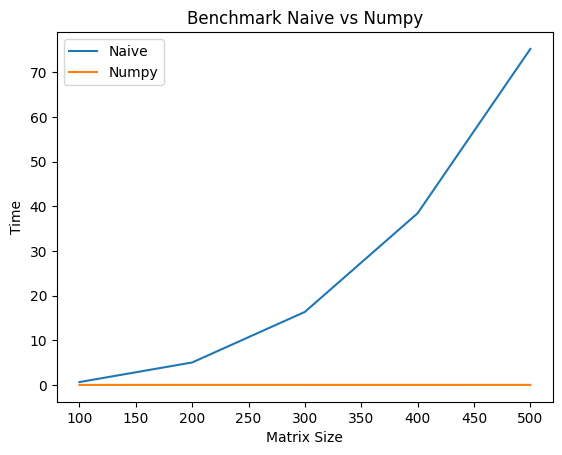

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=matrix_sizes, y=time_naive, label='Naive')
sns.lineplot(x=matrix_sizes, y=time_numpy, label='Numpy')

plt.ylabel('Time')
plt.xlabel('Matrix Size')
plt.title('Benchmark Naive vs Numpy')
plt.legend()
plt.show()

In [5]:
# 1.2
from numba import jit

@jit(nopython=True)
def matrix_product_optimization_1(mat_a, mat_b):
    """Returns the product of the matrices mat_a and mat_b."""
    m = mat_a.shape[0]
    n = mat_b.shape[1]

    assert(mat_a.shape[1] == mat_b.shape[0])

    ncol = mat_a.shape[1]

    mat_c = np.zeros((m, n), dtype=np.float64)

    for row_ind in range(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]

    return mat_c

In [6]:
from numba import njit, prange

@njit(parallel=True)
def matrix_product_optimization_2(mat_a, mat_b):
    """Returns the product of the matrices mat_a and mat_b."""
    m = mat_a.shape[0]
    n = mat_b.shape[1]

    assert(mat_a.shape[1] == mat_b.shape[0])

    ncol = mat_a.shape[1]

    mat_c = np.zeros((m, n), dtype=np.float64)

    for row_ind in prange(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]

    return mat_c

In [7]:
time_optimized_1 = []
time_optimized_2 = []

# run once to JIT compile
if True:
  a = np.random.randn(10, 10)
  b = np.random.randn(10, 10)

  matrix_product_optimization_1(a, b)
  matrix_product_optimization_2(a, b)

for i in tqdm(matrix_sizes):
  a = np.random.randn(i, i)
  b = np.random.randn(i, i)

  result_1 = %timeit -n 3 -r 5 -q -o matrix_product_optimization_1(a, b)
  result_2 = %timeit -n 3 -r 5 -q -o matrix_product_optimization_2(a, b)

  time_optimized_1.append(result_1.average)
  time_optimized_2.append(result_2.average)

100%|██████████| 5/5 [00:02<00:00,  1.68it/s]


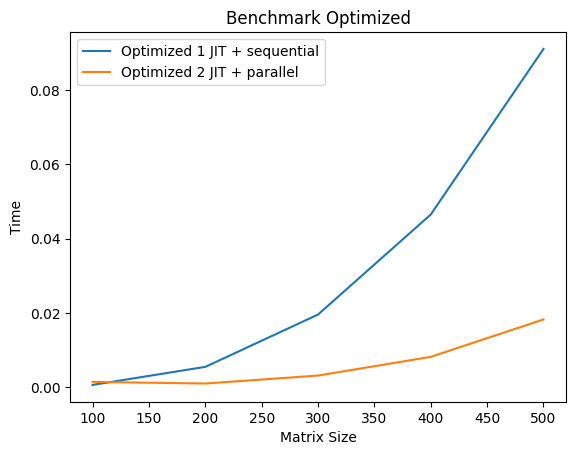

In [8]:
sns.lineplot(x=matrix_sizes, y=time_optimized_1, label='Optimized 1 JIT + sequential')
sns.lineplot(x=matrix_sizes, y=time_optimized_2, label='Optimized 2 JIT + parallel')

plt.ylabel('Time')
plt.xlabel('Matrix Size')
plt.title('Benchmark Optimized')
plt.legend()
plt.show()

#### A 1.2 Comment on the expected performance vs observed performance

The above plot shows that the parallel matrix_product is faster than the sequential implementation for bigger matrices.

In [12]:
# 1.3

time_optimized_1_fort = []
time_optimized_2_fort = []

# run once to JIT compile
if True:
  a = np.random.randn(10, 10)
  b = np.random.randn(10, 10)

  matrix_product_optimization_1(a, b)
  matrix_product_optimization_2(a, b)

for i in tqdm(matrix_sizes):
  a = np.random.randn(i, i)
  b = np.asfortranarray(np.random.randn(i, i))

  result_1 = %timeit -n 3 -r 5 -q -o matrix_product_optimization_1(a, b)
  result_2 = %timeit -n 3 -r 5 -q -o matrix_product_optimization_2(a, b)

  time_optimized_1_fort.append(result_1.average)
  time_optimized_2_fort.append(result_2.average)

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:03<00:00,  1.45it/s]


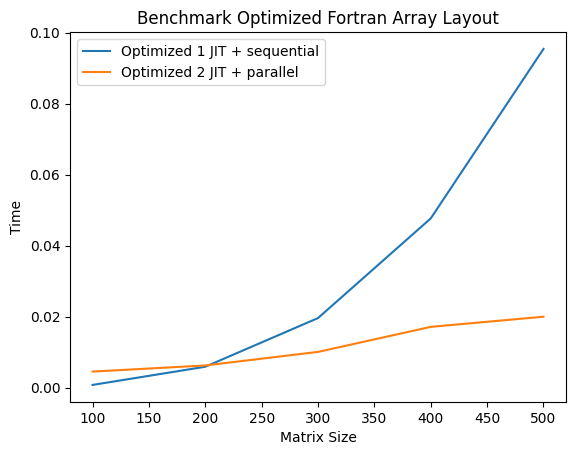

In [13]:
sns.lineplot(x=matrix_sizes, y=time_optimized_1_fort, label='Optimized 1 JIT + sequential')
sns.lineplot(x=matrix_sizes, y=time_optimized_2_fort, label='Optimized 2 JIT + parallel')

plt.ylabel('Time')
plt.xlabel('Matrix Size')
plt.title('Benchmark Optimized Fortran Array Layout')
plt.legend()
plt.show()

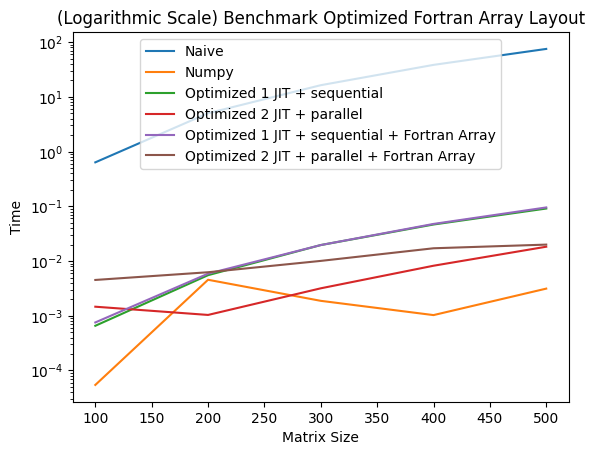

In [14]:
# summary
sns.lineplot(x=matrix_sizes, y=time_naive, label='Naive')
sns.lineplot(x=matrix_sizes, y=time_numpy, label='Numpy')
sns.lineplot(x=matrix_sizes, y=time_optimized_1, label='Optimized 1 JIT + sequential')
sns.lineplot(x=matrix_sizes, y=time_optimized_2, label='Optimized 2 JIT + parallel')
sns.lineplot(x=matrix_sizes, y=time_optimized_1_fort, label='Optimized 1 JIT + sequential + Fortran Array')
sns.lineplot(x=matrix_sizes, y=time_optimized_2_fort, label='Optimized 2 JIT + parallel + Fortran Array')

plt.ylabel('Time')
plt.xlabel('Matrix Size')
plt.title('(Logarithmic Scale) Benchmark Optimized Fortran Array Layout')
plt.yscale('log')
plt.legend()
plt.show()